# Research Workflow

This notebook demonstrates the research [workflow](https://langchain-ai.github.io/langgraph/tutorials/workflows/) that creates comprehensive reports through a series of focused steps. The system:

1. Uses a **graph workflow** with specialized nodes for each report creation stage
2. Enables user **feedback and approval** at critical planning points 
3. Produces a well-structured report with introduction, researched body sections, and conclusion

## From repo 

In [14]:
#To start a fresh venv, delete the old one in file explore
#Then use this command: python -m venv .venv
#Then activate it using python interpreter (ctr + shift + P)
#Select the venv path, then open new vs code terminal and you should see the (.venv)

In [15]:
%cd ..
%load_ext autoreload
%autoreload 2

c:\Users\vedan\GitHub\open_deep_research2
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## From package 

In [16]:
! pip install -U -q open-deep-research

# Compile the Graph-Based Research Workflow

The next step is to compile the LangGraph workflow that orchestrates the report creation process. This defines the sequence of operations and decision points in the research pipeline.

In [17]:
import uuid
import os, getpass
import sys
sys.path.append('/path/to/open_deep_research/src')  # Add the src directory to the path

from IPython.display import Image, display, Markdown
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from legacy.graph import builder  # Import from legacy.graph instead

In [18]:
# Create a memory-based checkpointer and compile the graph
# This enables state persistence and tracking throughout the workflow execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

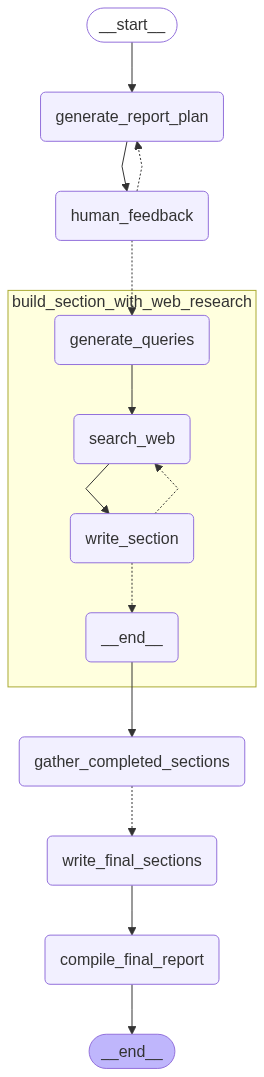

In [19]:
# Visualize the graph structure
# This shows the nodes and edges in the research workflow

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [20]:
# Helper function to set environment variables for API keys
# This ensures all necessary credentials are available for various services

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        

# Set the API keys used for any model or search tool selections below, such as:
#_set_env("OPENAI_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
#_set_env("TAVILY_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [21]:
# Define report structure template and configure the research workflow
# This sets parameters for models, search tools, and report organization

REPORT_STRUCTURE = """Use this structure to create a introduction on the user-provided topic:

You are a research paper summarizer assisting professors when they want to learn
more about a specific field. Your task is to generate a compelling
introduction about the topic that the professor inputs. You are also a top level researcher
in this field. You are extremly specific and detial orientented and that is shown in the
introductions that you write.The introduction should effectively summarize the current state
of research, identify a research gap, and highlight the novelty and contribution of the paper.
Avoid including irrelevant details or overly technical explanations that are not
necessary for an introduction. Use intext MLA citations. 

The introduction should be structured as follows:

1.  **Background:** Begin with a broad overview of the topic the researcher enters and the significance of the research topic.
Explain the existing challenges and the importance of addressing the problem.

2.  **Literature Review and Research Gap:** Summarize relevant previous work in the field. Discuss the limitations of existing approaches
and clearly articulate the research gap that this paper aims to address.

3.  **Contribution and Novelty:** Present the proposed solution and explain how it is innovative and different from previous work.
Clearly state the key contributions of this research and its potential impact.

The introduction should be written in a formal and academic tone, using precise language and technical jargon where appropriate.
It should be concise yet comprehensive, effectively capturing the essence of the paper. For now do not add the third section
(Contribution and Novelty) and inplace of that just put a placeholder. 

Make sure :
--> To double check each fact before using mentioning it in the report. 
--> That you are not just combining facts, but rather explaining a topic with facts and turning the report into a cohesive story. 
--> To synthesize information from multiple sources to provide a nuanced view  
--> To cross-verify key numbers to ensure the most accurate figure is used, especially when multiple sources offer slightly different values.

"""

# # Configuration option 1: Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            # "planner_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            # "writer_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# # Configuration option 2: DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

# Configuration option 3: Use OpenAI o3 for both planning and writing (selected option)
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "planner_model": "gpt-4o-mini",
                           "writer_provider": "openai",
                           "writer_model": "gpt-4o-mini",
                           "max_search_depth": 2,
                           "report_structure": REPORT_STRUCTURE,
                           }} 

# Define research topic about Model Context Protocol
topic = "Explore mars' shallow and deep interiors using seismic data and write me a proper research paper introduction about this topic."
# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Introduce the significance of exploring Mars' interiors using seismic data and the objectives of the report.
Research needed: No


Section: Background of Mars' Internal Structure
Description: Provide an overview of the current knowledge of Mars' structure, including the crust, mantle, and core, emphasizing the importance of seismic data gathering.
Research needed: Yes


Section: Current Seismic Research on Mars
Description: Discuss recent findings from the InSight mission regarding seismic activity on Mars, including the methodologies used to analyze seismic waves and their implications for understanding Mars' internal layers.
Research needed: Yes


Section: Analysis of Shallow and Deep Interiors
Description: Examine the differences in findings related to the shallow and deep interiors of Mars based on seismic data, focusing on layers identified with varying seismic velocities and their geological significance.
Research needed: Yes


Section: Comparison with Earth's Interior Structure
Description: Compare and contrast the interior structure and seismic activity of Mars with that of Earth, highlighting unique features discovered through seismic data on Mars.
Research needed: Yes


Section: Challenges in Seismic Data Analysis
Description: Identify and explain the challenges encountered in analyzing seismic data from Mars, including noise factors and data limitations, and how they affect our understanding of Martian geology.
Research needed: Yes


Section: Future Research Directions
Description: Suggest areas for future research based on current gaps and findings from seismic studies, and explain the potential impact of additional studies on our understanding of Mars.
Research needed: Yes


Section: Conclusion
Description: Summarize the main findings of the report and reiterate the importance of continued seismic studies in exploring and understanding Mars' geological history and internal structure.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# User Feedback Phase

* This allows for providing directed feedback on the initial report plan
* The user can review the proposed report structure and provide specific guidance
* The system will incorporate this feedback into the final report plan

In [22]:
# Submit feedback on the report plan
# The system will continue execution with the updated requirements

# Provide specific feedback to focus and refine the report structure
async for event in graph.astream(Command(resume=""), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: This section will introduce the topic of exploring Mars' shallow and deep interiors using seismic data, establishing the significance of the research in understanding planetary formation and evolution.
Research needed: No


Section: Mars' Interior Structure
Description: This section will outline the current understanding of Mars' internal structure, including its crust, mantle, and core, and discuss how seismic data contributes to revealing these layers.
Research needed: Yes


Section: The InSight Mission
Description: This section will provide an overview of the InSight mission, detailing its objectives, methodologies, and the innovative seismological tools used to study Mars.
Research needed: Yes


Section: Seismic Activity on Mars
Description: This section will review the seismic activity detected by the InSight mission, including the significance of marsquakes and their implications for understanding Mars' geological processes.
Research needed: Yes


Section: Seismic Data Analysis Techniques
Description: This section will discuss the various techniques used to analyze seismic data collected by InSight, including how these methodologies can help identify Mars' internal structure.
Research needed: Yes


Section: Conclusion
Description: This final section will summarize the findings related to Mars' interior exploration and discuss the future directions for research, highlighting the potential contributions to planetary science.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# Final Approval Phase
* After incorporating feedback, approve the plan to start content generation

In [23]:
# Approve the final plan and execute the report generation
# This triggers the research and writing phases for all sections

# The system will now:
# 1. Research each section topic
# 2. Generate content with citations
# 3. Create introduction and conclusion
# 4. Compile the final report

async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name="Mars' Interior Structure", description="This section will outline the current understanding of Mars' internal structure, including its crust, mantle, and core, and discuss how seismic data contributes to revealing these layers.", research=True, content="## Mars' Interior Structure\n\nOur understanding of Mars' internal structure has evolved significantly, particularly with the NASA InSight mission's deployment of the Seismic Experiment for Interior Structure (SEIS). This mission, which began collecting seismic data in early 2019, has become instrumental in revealing the intricacies of Mars' crust, mantle, and core. Studies indicate that Mars features a layered crust with estimated thickness ranging from 24 km to 72 km, influenced by a complex history involving a primordial magma ocean that solidified into a differentiated structure [4][5].\n\nRecent findings have provided constraints on

In [ ]:
# Display the final generated report
# Retrieve the completed report from the graph's state and format it for display

final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

The exploration of Mars' shallow and deep interiors through seismic data holds immense significance for our understanding of the planet's geological history and evolution. By utilizing data from the NASA InSight mission, scientists have mapped Mars' internal structure, revealing intricacies of its crust, mantle, and core. Key findings include the identification of a layered crust up to 72 kilometers thick and a large liquid core, shedding light on planetary formation processes.

Main body sections of this report will delve into the details of Mars' interior structure, the innovative methodologies employed by the InSight mission, significant seismic activity detected on the planet, and the advanced data analysis techniques utilized to interpret this seismic information. Together, these insights contribute to a comprehensive understanding of Mars' geological dynamics and its place among terrestrial planets.

## Mars' Interior Structure

Our understanding of Mars' internal structure has evolved significantly, particularly with the NASA InSight mission's deployment of the Seismic Experiment for Interior Structure (SEIS). This mission, which began collecting seismic data in early 2019, has become instrumental in revealing the intricacies of Mars' crust, mantle, and core. Studies indicate that Mars features a layered crust with estimated thickness ranging from 24 km to 72 km, influenced by a complex history involving a primordial magma ocean that solidified into a differentiated structure [4][5].

Recent findings have provided constraints on the Martian mantle, suggesting it exhibits a cooling and differentiated state that accommodates a large, presumably liquid core with a radius of approximately 1830 km [4][6]. This suggests the core contains lighter alloying elements, distinguishing it from Earth’s core [8]. InSight’s seismic data not only illuminate the architecture of these layers but also enhance our comprehension of Mars' thermal and evolutionary history [3][9]. Mapping these internal structures is crucial, as it informs theories concerning planetary formation and the broader understanding of terrestrial planets.

### Sources
[1] Crust, mantle and core structure of Mars from InSight seismic data: https://ui.adsabs.harvard.edu/abs/2021EPSC...15..512K/abstract  
[2] How scientists have been looking inside Mars: https://www.weforum.org/stories/2021/07/how-scientists-have-been-looking-inside-mars/  
[3] Mars Interior and Geophysics Before InSight: https://www.hou.usra.edu/meetings/marsinterior2024/presentations/Tuesday/0830_Banerdt.pdf  
[4] Mars Interior Structure Revealed by InSight Seismic Data: https://www.astro.oma.be/en/mars-interior-structure-revealed-by-insight-seismic-data/  
[5] Thickness and structure of the martian crust from InSight seismic data: https://www.science.org/doi/10.1126/science.abf8966  
[6] Seismic detection of the martian core: https://www.science.org/doi/10.1126/science.abi7730  
[7] Geophysical evidence for an enriched molten silicate layer above Mars’s core: https://www.nature.com/articles/s41586-023-06601-8  
[8] Seismic data reveal Mars's molten mantle: https://pubs.aip.org/physicstoday/online/42912/Seismic-data-reveal-Mars-s-molten-mantle  
[9] First observations of core-transiting seismic phases on Mars: https://www.pnas.org/doi/10.1073/pnas.2217090120  

## The InSight Mission

The InSight mission, aptly named for its aim of investigating the interior of Mars, represents a significant advancement in planetary science. Launched on May 5, 2018, and landing on November 26, 2018, InSight uniquely employs a lander equipped with sophisticated instrumentation to study Mars's deep interior. The mission primarily focuses on understanding the planet's geological formation, including the size and state of its core, the composition of its mantle, and the characteristics of its crust, providing insights comparable to Earth's geological structure [2](https://en.wikipedia.org/wiki/InSight) [3](https://an.rsl.wustl.edu/help/Content/About%20the%20mission/INS/InSight%20mission.htm).

At the heart of InSight's scientific endeavors are three key instruments: the Seismic Experiment for Interior Structure (SEIS), the Heat Flow and Physical Properties Package (HP3), and the Rotation and Interior Structure Experiment (RISE). SEIS captures seismic waves to detect marsquakes, while HP3 probes the Martian crust to measure thermal properties. Finally, RISE tracks the lander’s position to analyze Mars's internal structure [7](https://science.nasa.gov/mission/insight/science-instruments/) [9](https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/). Together, these instruments enable scientists to unravel details about Mars's evolution and geological activity, contributing to our understanding of terrestrial planet formation [1](https://ieeexplore.ieee.org/document/8396723/) [4](https://science.nasa.gov/mission/insight/science/).

### Sources
[1] InSight: Mission to Mars - https://ieeexplore.ieee.org/document/8396723/  
[2] InSight - https://en.wikipedia.org/wiki/InSight  
[3] InSight mission - https://an.rsl.wustl.edu/help/Content/About%20the%20mission/INS/InSight%20mission.htm  
[4] InSight Science - https://science.nasa.gov/mission/insight/science/  
[5] InSight Mars - Department of Geophysics - https://geophysics.mines.edu/project/insight-mars/  
[6] InSight mission unveils the interior of Mars - Imperial College London - https://www.imperial.ac.uk/news/227033/insight-mission-unveils-interior-mars/  
[7] InSight Science Instruments - https://science.nasa.gov/mission/insight/science-instruments/  
[8] SEISmometer for the Mars-Mission Insight - MPS - https://www.mps.mpg.de/planetary-science/insight-seis  
[9] How InSight Revealed the Heart of Mars – Teachable Moment - https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/  

## Seismic Activity on Mars

The InSight mission has significantly advanced our understanding of seismic activity on Mars, detecting over 1,300 marsquakes since its arrival on the planet in 2018. Unlike Earth, where seismic activity is shaped by tectonic plate movements, Mars's seismic events typically result from the cooling and contraction of a single tectonic plate, leading to stress release and faults formation. Most of these marsquakes are beneath the Martian surface and demonstrate considerable energy, with the largest recorded event reaching a magnitude of 5.0 in May 2022[5][7].

The mission's primary instrument, the Seismic Experiment for Interior Structure (SEIS), captures seismic waves that provide insights into Mars' internal structure. By analyzing these waves, researchers have identified three distinct crustal layers, each with varying compositions and densities, and confirmed the presence of a liquid core beneath[6][7]. The variety of detected events, including those caused by meteoroid impacts, further enhances our understanding of Mars's geological processes and internal dynamics, ultimately laying the groundwork for comparing its geology with that of Earth[4][6][8].

### Sources
[1] Seismic sources of InSight marsquakes and seismotectonic ...: https://www.sciencedirect.com/science/article/pii/S0040195122002281  
[2] Seismic Data from Mars! | SAGE: https://www.iris.edu/hq/sis/insight  
[3] Seismology on Mars: An analysis of direct, reflected, and ...: https://www.sciencedirect.com/science/article/pii/S0031920122000127  
[4] Marsquakes: The InSight experiment: https://www.geological-digressions.com/marsquakes-the-insight-experiment/  
[5] How InSight Revealed the Heart of Mars – Teachable Moment: https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/  
[6] InSight registers seismic signal on Mars - Max-Planck-Gesellschaft: https://www.mpg.de/13379141/insight-registers-seismic-signal-on-mars  
[7] NASA's InSight Mission Reveals the Detailed Internal Structure of Mars: https://scitechdaily.com/nasas-insight-mission-reveals-the-detailed-internal-structure-of-mars/  
[8] Marsquake Locations and 1‐D Seismic Models for Mars From ...: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021JE007067   

## Seismic Data Analysis Techniques

The InSight mission utilizes various advanced techniques for seismic data analysis to understand the internal structure of Mars. One primary method used is ambient noise autocorrelation, which involves analyzing continuous seismic data collected by the lander over time. This technique can extract valuable information about the planet’s crust and mantle by identifying how seismic waves interact with different geological layers beneath the surface [1].

Another technique is the application of machine learning, specifically convolutional neural networks (CNNs), which enhance the detection of marsquakes by filtering out noise and classifying seismic events. This method involves transforming the seismic data into a time-frequency representation, allowing for more accurate event detection and noise reduction [5]. The Marsquake Service (MQS) also plays a vital role in cataloging seismic events, ensuring comprehensive documentation of all detected marsquakes and their characteristics [4] [2].

Through these methodologies, InSight has successfully mapped the crust's characteristics and identified features such as the Martian core, shedding light on the planet's composition and evolution [7][6]. This collaborative approach between seismology and machine learning enriches our understanding of Mars' geology and tectonic activity.

### Sources
[1] InSight (Interior Exploration using Seismic Investigations, Geodesy ... - https://www.eoportal.org/satellite-missions/insight  
[2] Searching the InSight Seismic Data for Mars's Background‐Free ... - https://pubs.geoscienceworld.org/ssa/srl/article/96/1/377/649779/Searching-the-InSight-Seismic-Data-for-Mars-s  
[3] Analysis of NASA InSight Data Suggests Mars Hit by Meteoroids ... - https://www.aau.edu/research-scholarship/featured-research-topics/analysis-nasa-insight-data-suggests-mars-hit  
[4] Detection, Analysis, and Removal of Glitches From InSight's Seismic ... - https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2020EA001317  
[5] Marsquake Detection with Machine Learning Methods - EGU Blogs - https://blogs.egu.eu/divisions/sm/2022/12/19/marsquakes-and-machine-learning/  
[6] Seismic Experiment for Interior Structure - Wikipedia - https://en.wikipedia.org/wiki/Seismic_Experiment_for_Interior_Structure  
[7] InSight Mission: Mars unveiled - CNRS - https://www.cnrs.fr/en/press/insight-mission-mars-unveiled  

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

The exploration of Mars' internal structure has gained momentum thanks to groundbreaking missions like NASA’s InSight. This report delves into the seismic data collected by InSight, focusing on its contributions to our understanding of Mars' crust, mantle, and core. By analyzing over 1,300 detected marsquakes, this research unveils critical insights into the planet’s geological history and composition. The innovative seismic instruments employed by InSight, particularly the Seismic Experiment for Interior Structure (SEIS), reveal the complexities of Mars' layered crust and possibly liquid core, enhancing our understanding of its evolution as a terrestrial planet. 

## Conclusion

In conclusion, the exploration of Mars' interior using seismic data has profoundly advanced our knowledge of its geological structure. The InSight mission revealed a layered crust of varying thickness, a differentiated mantle, and a considerable liquid core, illustrating Mars' complex thermal evolution. Key findings from the detected marsquakes showed distinct crustal layers and offered insights into its tectonic processes, fundamentally comparing Mars with Earth’s geology. 

| Key Findings                          | Implications                                  |
|---------------------------------------|-----------------------------------------------|
| Layered crust between 24 km and 72 km| Inform theories of planetary formation         |
| Presumed liquid core with lighter alloys| Deepens understanding of planetary core compositions |
| Detection of over 1,300 marsquakes   | Enhances knowledge of Mars's geological activity|

Future research should focus on further analyzing the core’s composition and investigating seismic activity to deepen our understanding of planetary evolution across different celestial bodies.

In [38]:
import os
import re # Import regular expression module
from IPython.display import FileLink, display

# Define the base filename for your report
base_report_filename = "generated_research_report"
file_extension = ".md"

# Define the directory to save the report (e.g., current directory)
output_directory = os.getcwd()
output_directory += "\src\legacy\\reports"

# --- Find the next available edition number ---
next_edition_number = 1
existing_reports = []

# List all files in the output directory
try:
    for filename in os.listdir(output_directory):
        # Check if the filename matches our pattern (e.g., generated_research_report_X.md)
        match = re.match(rf"^{re.escape(base_report_filename)}_(\d+){re.escape(file_extension)}$", filename)
        if match:
            # Extract the number and add it to our list
            existing_reports.append(int(match.group(1)))

    if existing_reports:
        # If reports exist, the next edition is the highest existing number + 1
        next_edition_number = max(existing_reports) + 1

except FileNotFoundError:
    print(f"Directory not found: {output_directory}. Assuming first report.")
except Exception as e:
    print(f"Error while checking existing reports: {e}. Starting with edition 1.")

# Construct the new filename with the edition number
report_filename = f"{base_report_filename}_{next_edition_number}{file_extension}"
output_filepath = os.path.join(output_directory, report_filename)

print(f"Attempting to save report as: {report_filename} to: {output_filepath}")

try:
    with open(output_filepath, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"Report saved successfully to: {output_filepath}")

    # Verify if the file actually exists after writing
    if os.path.exists(output_filepath):
        print(f"Confirmation: File exists at {output_filepath}")
        # Create a download link - use the relative path for FileLink
        display(FileLink(report_filename))
    else:
        print(f"ERROR: File was NOT found at {output_filepath} immediately after writing.")

except PermissionError:
    print(f"ERROR: Permission denied. Cannot write to {output_filepath}.")
    print("Please check write permissions for this directory.")
except Exception as e:
    print(f"An unexpected error occurred while saving the report: {e}")


Attempting to save report as: generated_research_report_6.md to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_6.md
Report saved successfully to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_6.md
Confirmation: File exists at c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_6.md


c:\Users\vedan\GitHub\open_deep_research2\generated_research_report_6.md